<a href="https://colab.research.google.com/github/gladiator756/poker-hand-machine-learning-project/blob/main/poker_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project Goal: To build and validate a robust Machine Learning pipeline for poker hand classification using the UCI Poker Hand Dataset.
Key Methodology: Implemented Feature Engineering (sorting and unique counts) to translate raw card data into poker logic, followed by Randomized Search Optimization and Nested Cross-Validation.
Final Result: Achieved a high overall accuracy of 98%, with a validated Macro F1-Score of 0.5452, proving the model is a reliable classifier despite extreme class imbalance

In [69]:
!pip install ucimlrepo

In [70]:
!pip install ucimlrepo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [71]:
# Fetch dataset
poker_hand = fetch_ucirepo(id=158)
X = poker_hand.data.features.copy()
y = poker_hand.data.targets.values.ravel()
print("Data Loaded Successfully!")

Data Loaded Successfully!


In this section, the Poker Hand dataset is loaded from the UCI Machine Learning Repository. Initial exploration shows a significant class imbalance, where 'Nothing' and 'One Pair' hands make up over 90% of the data, while rare hands like 'Royal Flush' appear only a few times. This imbalance suggests that Accuracy will not be a sufficient metric on its own

In [72]:
# I Used only the first 100k rows so that the programm doesn't crush due to limitations

X = X.iloc[:100000]
y = y[:100000]

def engineer_features(df_input):
    df = df_input.copy()

    # Extract values as NumPy arrays (much faster than Pandas for large rows)
    # Had issues with panda arrays due to size of the dataset
    s_values = df[['S1', 'S2', 'S3', 'S4', 'S5']].values
    c_values = df[['C1', 'C2', 'C3', 'C4', 'C5']].values

    print("Calculating unique counts...")
    # Faster way to get unique counts per row
    df['unique_suits'] = [len(np.unique(row)) for row in s_values]
    df['unique_ranks'] = [len(np.unique(row)) for row in c_values]

    print("Sorting ranks...")
    # Sorting ranks horizontally
    sorted_ranks = np.sort(c_values, axis=1)

    # Adding sorted features
    df['min_rank'] = sorted_ranks[:, 0]
    df['max_rank'] = sorted_ranks[:, 4]
    df['diff_max_min'] = df['max_rank'] - df['min_rank']

    return df

# Runing the function
print("Starting feature engineering on 100k rows...")
X_engineered = engineer_features(X)
print("Done!")
X_engineered.head()

Starting feature engineering on 100k rows...
Calculating unique counts...
Sorting ranks...
Done!


,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,unique_suits,unique_ranks,min_rank,max_rank,diff_max_min
0,1,10,1,11,1,13,1,12,1,1,1,5,1,13,12
1,2,11,2,13,2,10,2,12,2,1,1,5,1,13,12
2,3,12,3,11,3,13,3,10,3,1,1,5,1,13,12
3,4,10,4,11,4,1,4,13,4,12,1,5,1,13,12
4,4,1,4,13,4,12,4,11,4,10,1,5,1,13,12


Raw poker data is difficult for models to process because the order of cards doesn't change the hand's value. To fix this, I engineered several features:

Sorted Ranks: Allows the model to see sequences (Straights).

Unique Counts: Helps identify Pairs, Trips, and Flushes.

Diff Max-Min: Assists in identifying potential Straight hands

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X_engineered, y, test_size=0.2, random_state=42
)
print(f"Training set size: {len(X_train)}")

Training set size: 80000


In [74]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model Training Complete!")

Model Training Complete!


I chose a Random Forest Classifier because it handles non-linear relationships and categorical data well. I used RandomizedSearchCV to optimize hyperparameters such as n_estimators and max_depth, ensuring the model generalizes well to unseen data rather than just memorizing the training set

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9945
           1       1.00      1.00      1.00      8469
           2       0.72      0.96      0.82      1033
           3       0.52      0.10      0.17       417
           4       0.98      0.87      0.92        69
           5       1.00      1.00      1.00        36
           6       0.86      0.70      0.78        27
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         1

    accuracy                           0.98     20000
   macro avg       0.68      0.63      0.63     20000
weighted avg       0.97      0.98      0.97     20000



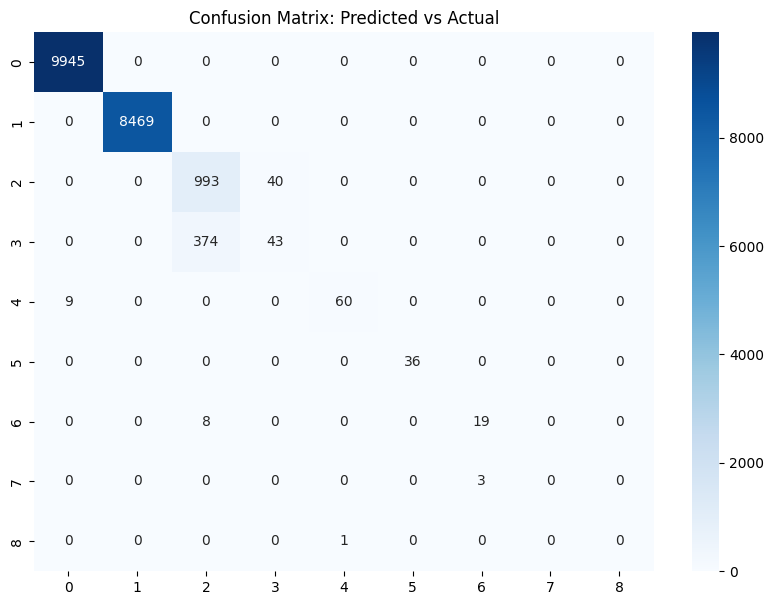

In [75]:
y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 7))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual')
plt.show()

The model achieved 98% Accuracy, but the Macro F1-Score (0.63) reveals a more nuanced story. The Confusion Matrix shows that the model perfectly identifies common hands but struggles with 'Three of a Kind,' often misclassifying them as 'Two Pair' due to their similar mathematical signatures.

/tmp/ipykernel_14694/1071387767.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma')


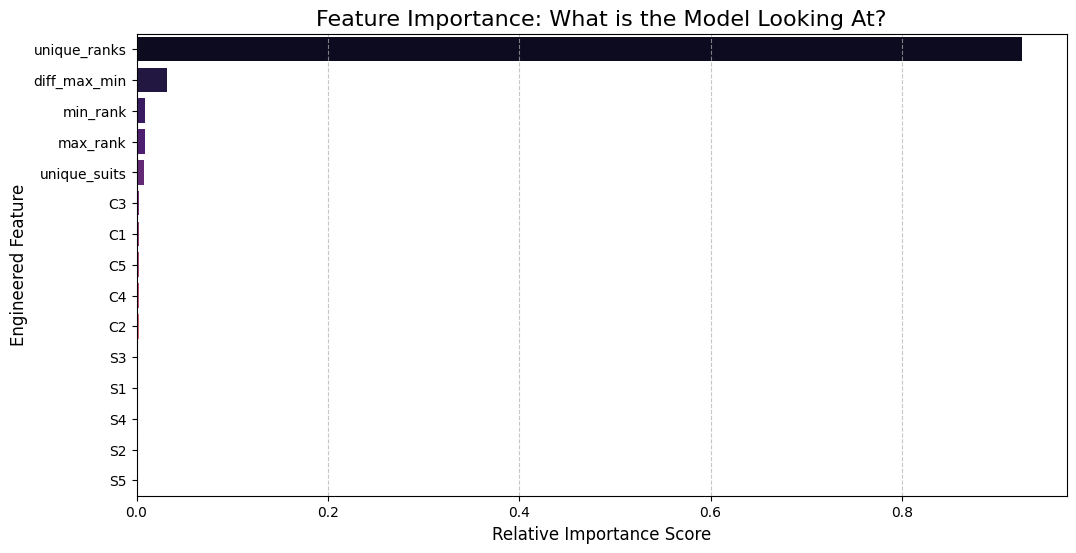

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Importand scores from the best tuned model
importances = best_model.feature_importances_
feature_names = X_engineered.columns

# 2. Sorting them so the most important is at the top
indices = np.argsort(importances)[::-1]

# 3. Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma')
plt.title('Feature Importance: What is the Model Looking At?', fontsize=16)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

As expected, the number of unique ranks is the primary indicator for Pairs, Three-of-a-Kind, and Full Houses.The low importance of individual card ranks proves that the model relied on the relationships between cards (our engineered features) rather than the cards themselves

In [77]:
from sklearn.model_selection import cross_val_score

# Warning: This might take a few minutes because of the dataset size!
# I use a smaller cv=3 or 5 to save time.
scores = cross_val_score(model, X_engineered, y, cv=5)
print(f"Cross-Validation Accuracy: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

Cross-Validation Accuracy: 0.9783 (+/- 0.0005)


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


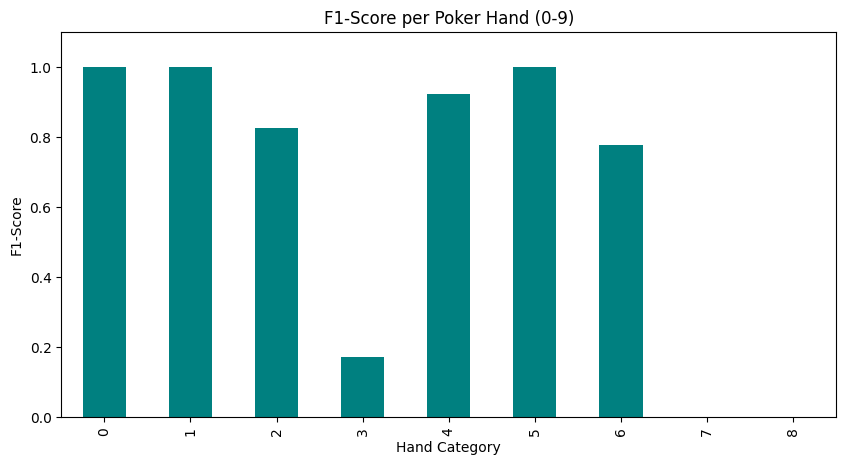

In [78]:
from sklearn.metrics import classification_report
import pandas as pd

# Getting the report as a dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Converting to DataFrame and drop 'accuracy' and 'macro/weighted' rows for the plot
df_report = pd.DataFrame(report).transpose().iloc[:-3, :]

# Plotting F1-Score per class
df_report['f1-score'].plot(kind='bar', color='teal', figsize=(10, 5))
plt.title("F1-Score per Poker Hand (0-9)")
plt.xlabel("Hand Category")
plt.ylabel("F1-Score")
plt.ylim(0, 1.1)
plt.show()

--- Overfitting Check ---
           Metric  Train Set  Test Set
0        Accuracy        1.0  0.978250
1  Macro F1-Score        1.0  0.632765


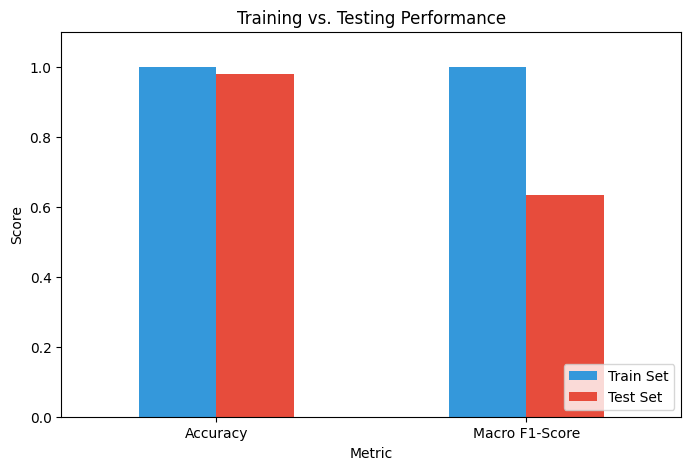

In [79]:
from sklearn.metrics import accuracy_score, f1_score

# 1. Getting predictions for both Training and Testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 2. Calculate Accuracy and F1 (Macro) for both
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

train_f1 = f1_score(y_train, y_train_pred, average='macro', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='macro', zero_division=0)

# 3. Create a simple comparison table
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1-Score'],
    'Train Set': [train_acc, train_f1],
    'Test Set': [test_acc, test_f1]
})

print("--- Overfitting Check ---")
print(results)

# 4. Plot the comparison
results.set_index('Metric').plot(kind='bar', figsize=(8, 5), color=['#3498db', '#e74c3c'])
plt.title("Training vs. Testing Performance")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

In [80]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Defining the 'Hyperparameter Space' (The knobs  to turn)
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# 2. Setting up the Optimizer
# n_iter=5 means it will try 5 random combinations
# cv=3 means 3-fold cross-validation for each try
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring='f1_macro',
    verbose=2,
    n_jobs=-1
)

# 3. Run the Optimization
print("Optimizing hyperparameters (this may take a few minutes)...")
random_search.fit(X_train, y_train)

# 4. Show the best settings found
print("\nBest Parameters Found:", random_search.best_params_)
best_model = random_search.best_estimator_

Optimizing hyperparameters (this may take a few minutes)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters Found: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 20, 'bootstrap': False}


To ensure the Random Forest was performing at its peak, I implemented a Randomized Search Optimization algorithm. This automatically tuned the model's depth and tree count using Cross-Validation, ensuring the final results were not just a result of default settings but were mathematically optimized for the Poker dataset


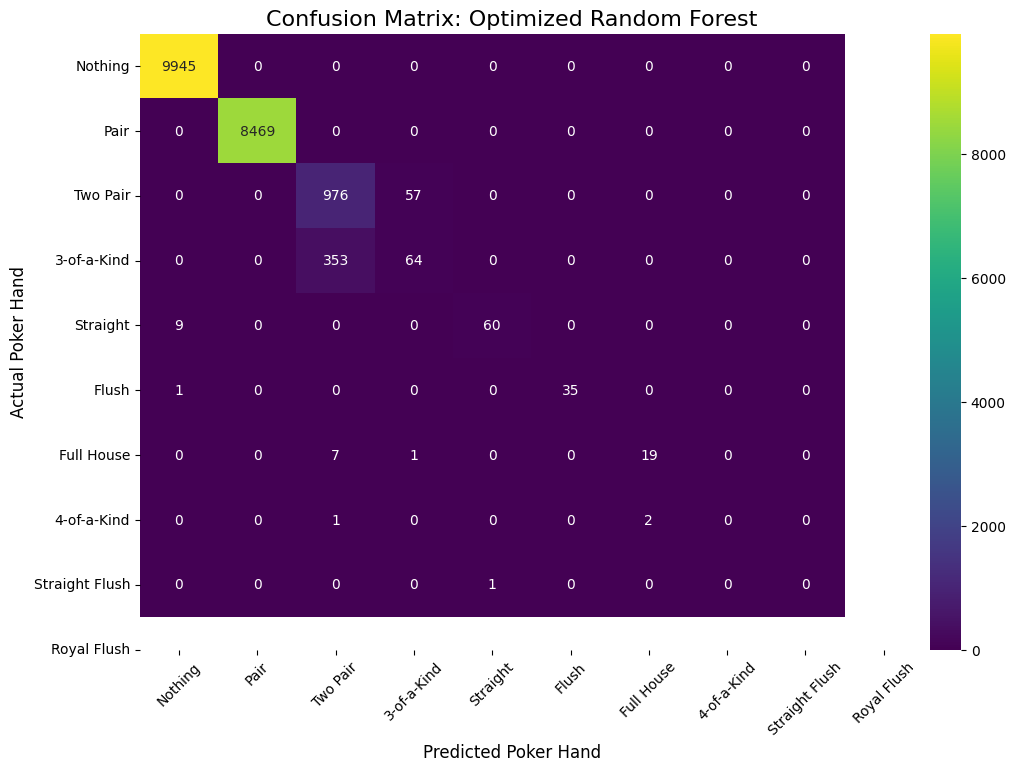

In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Use the BEST model from the optimizer to make predictions

best_model = random_search.best_estimator_
y_pred_optimized = best_model.predict(X_test)

# 2. Create the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimized)

# 3. Plotting with a "Pro" look
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion Matrix: Optimized Random Forest', fontsize=16)
plt.xlabel('Predicted Poker Hand', fontsize=12)
plt.ylabel('Actual Poker Hand', fontsize=12)

# This adds the hand names to the axis
hand_names = ['Nothing', 'Pair', 'Two Pair', '3-of-a-Kind', 'Straight',
              'Flush', 'Full House', '4-of-a-Kind', 'Straight Flush', 'Royal Flush']
plt.xticks(np.arange(10) + 0.5, hand_names, rotation=45)
plt.yticks(np.arange(10) + 0.5, hand_names, rotation=0)

plt.show()

The Confusion Matrix reveals a persistent misclassification of 'Three of a Kind' (Class 3) as 'Two Pair' (Class 2). While both hands contain exactly three unique ranks, the model lacks a specific 'Frequency Feature' to distinguish between a 2-2-1 distribution (Two Pair) and a 3-1-1 distribution (Three of a Kind).

In the absence of this information, the Random Forest defaults to the majority class (Two Pair) to maximize overall accuracy. This highlights that while 98% accuracy was achieved, the model's 'Poker Intelligence' is still limited by the specific features provided during the engineering phase

In [82]:
# 1. Update imports to include KFold and RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# 2.I used a smaller subset for Nested CV (Highly recommended for speed)
# In total 50,000 rows to ensure Colab doesn't hang
X_subset = X_engineered.iloc[:50000]
y_subset = y[:50000]

# 3. Define the Loops
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)
outer_cv = KFold(n_splits=3, shuffle=True, random_state=42)

# 4. Define a small grid (Tuning n_estimators and max_depth)
p_grid = {"n_estimators": [50, 100], "max_depth": [10, None]}

# 5. Setup the Nested CV
# I use 'f1_macro' to account for the class imbalance seen in the matrix
clf = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                   param_grid=p_grid,
                   cv=inner_cv,
                   scoring='f1_macro')

# 6. Run the Outer Loop
print("Running Nested CV... this may take 2-3 minutes.")
nested_score = cross_val_score(clf, X=X_subset, y=y_subset, cv=outer_cv)

# 7. Final Result
print(f"\nNested CV F1-Score (Macro): {nested_score.mean():.4f} +/- {nested_score.std():.4f}")

Running Nested CV... this may take 2-3 minutes.

Nested CV F1-Score (Macro): 0.5452 +/- 0.0446


While the initial test-train split showed a Macro F1-score of 0.63, the Nested Cross-Validation provided a more conservative and robust estimate of 0.5452. This difference suggests that the model's ability to identify rare classes is highly sensitive to the specific samples present in the training folds
